# 05 Model Tuning on Dev-Clean (Baseline MLP)

This notebook performs **model tuning** using only dev-clean data.

Tuning targets in this notebook:
- model checkpoint selection (compare multiple trained checkpoints)
- decision threshold selection (choose threshold that maximizes dev F1)

No test-clean data is used in this notebook.

### Step 1: Import libraries
This step imports plotting, metrics, tensor, and utility libraries used throughout validation and checkpoint comparison.

In [1]:
import json
import sys
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    )

### Step 2: Resolve project paths and runtime config
This step finds the repository root, adds Step 05 modules to Python path, and sets shared configuration such as data paths, device, checkpoint filters, and threshold grid.

In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / 'src').exists() and (candidate / 'data' / 'generated').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root from current working directory.')

ROOT = find_project_root(Path.cwd())
SRC_05 = ROOT / 'src' / '05_baseline_training'
if str(SRC_05) not in sys.path:
    sys.path.insert(0, str(SRC_05))

from baseline_mlp import BaselineMLP
from offline_dataset import build_dataloader

DATA_ROOT = ROOT / 'data' / 'generated'
ARTIFACTS_DIR = ROOT / 'artifacts'
CHECKPOINT_DIR = ARTIFACTS_DIR / 'checkpoints'

BATCH_SIZE = 2048
NUM_WORKERS = 4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CHECKPOINT_SUFFIXES = {'.pt', '.pth', '.ckpt'}
CHECKPOINT_NAME_CONTAINS = 'baseline_mlp'
THRESHOLDS = np.linspace(0.05, 0.95, 19)
TOP_K_PLOTS = 10

print('Project root        :', ROOT)
print('Step 05 src         :', SRC_05)
print('Data root           :', DATA_ROOT)
print('Checkpoint directory:', CHECKPOINT_DIR)
print('Device              :', DEVICE)

Project root        : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL
Step 05 src         : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/src/05_baseline_training
Data root           : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated
Checkpoint directory: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/checkpoints
Device              : cuda


### Step 3: Define checkpoint/model helper functions
This step defines reusable helpers for loading checkpoint formats, inferring model shape, constructing the model safely, and collecting logits/labels from the dataloader.

In [3]:
def _extract_state_dict(obj):
    if isinstance(obj, dict):
        if 'state_dict' in obj and isinstance(obj['state_dict'], dict):
            return obj['state_dict']
        if 'model_state_dict' in obj and isinstance(obj['model_state_dict'], dict):
            return obj['model_state_dict']
    return obj


def _infer_mlp_shape_from_state(state_dict):
    linear_layers = []
    for k, v in state_dict.items():
        if not (k.startswith('backbone.') and k.endswith('.weight')):
            continue
        if not hasattr(v, 'shape') or len(v.shape) != 2:
            continue
        parts = k.split('.')
        if len(parts) < 3 or not parts[1].isdigit():
            continue
        idx = int(parts[1])
        out_dim, in_dim = int(v.shape[0]), int(v.shape[1])
        linear_layers.append((idx, in_dim, out_dim))

    if not linear_layers:
        raise RuntimeError('Could not infer backbone layers from checkpoint state_dict.')

    linear_layers.sort(key=lambda t: t[0])
    input_dim = linear_layers[0][1]
    hidden_dims = tuple(layer[2] for layer in linear_layers)
    dropout = 0.1 if len(linear_layers) >= 2 and (linear_layers[1][0] - linear_layers[0][0] == 3) else 0.0
    return input_dim, hidden_dims, dropout


def load_model_from_checkpoint(checkpoint_path: Path, device: torch.device) -> BaselineMLP:
    raw = torch.load(checkpoint_path, map_location='cpu')
    state = _extract_state_dict(raw)
    if not isinstance(state, dict):
        raise RuntimeError('Checkpoint does not contain a valid state_dict.')

    input_dim, hidden_dims, dropout = _infer_mlp_shape_from_state(state)
    model = BaselineMLP(input_dim=input_dim, hidden_dims=hidden_dims, dropout=dropout)
    model.load_state_dict(state, strict=True)
    model.to(device)
    model.eval()
    return model


def collect_logits_labels(loader, model, device):
    logits_all = []
    labels_all = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x).detach().cpu().numpy()
            labels = y.detach().cpu().numpy().astype(np.int64)
            logits_all.append(logits)
            labels_all.append(labels)

    if not logits_all:
        raise RuntimeError('No samples collected from loader.')

    return np.concatenate(logits_all), np.concatenate(labels_all)

### Step 4: Build dev dataloader and discover checkpoints
This step builds the dev-clean dataloader and scans artifacts/checkpoints for candidate model files to evaluate.

In [4]:
loader = build_dataloader(
    generated_dir=DATA_ROOT / 'dev',
    split='dev',
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

ckpt_candidates = sorted(
    [
        p for p in CHECKPOINT_DIR.rglob('*')
        if p.is_file() and p.suffix in CHECKPOINT_SUFFIXES
    ]
)
if CHECKPOINT_NAME_CONTAINS:
    key = CHECKPOINT_NAME_CONTAINS.lower()
    ckpt_candidates = [p for p in ckpt_candidates if key in p.name.lower()]

print('Dataset size          :', len(loader.dataset))
print('Checkpoint candidates :', len(ckpt_candidates))
for p in ckpt_candidates[:20]:
    print(' -', p.name)

if not ckpt_candidates:
    raise FileNotFoundError(f'No checkpoint files found under: {CHECKPOINT_DIR}')

Dataset size          : 1088453
Checkpoint candidates : 12
 - baseline_mlp_lr0.0003_wd0_dr0.0_seed42.pt
 - baseline_mlp_lr0.0003_wd0_dr0.1_seed42.pt
 - baseline_mlp_lr0.0003_wd1e-4_dr0.0_seed42.pt
 - baseline_mlp_lr0.0003_wd1e-4_dr0.1_seed42.pt
 - baseline_mlp_lr0.0003_wd1e-5_dr0.0_seed42.pt
 - baseline_mlp_lr0.0003_wd1e-5_dr0.1_seed42.pt
 - baseline_mlp_lr0.001_wd0_dr0.0_seed42.pt
 - baseline_mlp_lr0.001_wd0_dr0.1_seed42.pt
 - baseline_mlp_lr0.001_wd1e-4_dr0.0_seed42.pt
 - baseline_mlp_lr0.001_wd1e-4_dr0.1_seed42.pt
 - baseline_mlp_lr0.001_wd1e-5_dr0.0_seed42.pt
 - baseline_mlp_lr0.001_wd1e-5_dr0.1_seed42.pt


### Step 5: Evaluate all checkpoints and tune threshold per checkpoint
This step runs inference for each checkpoint on dev-clean, performs threshold sweep, records best metrics for each model, and selects the top checkpoint by best dev F1.

In [5]:
def metrics_at_threshold(probs, labels, thr=0.5):
    pred = (probs >= thr).astype(np.int64)
    y = labels.astype(np.int64)

    tp = int(np.sum((pred == 1) & (y == 1)))
    tn = int(np.sum((pred == 0) & (y == 0)))
    fp = int(np.sum((pred == 1) & (y == 0)))
    fn = int(np.sum((pred == 0) & (y == 1)))

    acc = (tp + tn) / max(1, tp + tn + fp + fn)
    prec = tp / max(1, tp + fp)
    rec = tp / max(1, tp + fn)
    f1 = (2.0 * prec * rec) / max(1e-12, (prec + rec))

    return {
        'threshold': float(thr),
        'accuracy': float(acc),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
    }


results = []
failures = []

best_model = None
all_logits = None
all_labels = None
probs = None

for i, ckpt in enumerate(ckpt_candidates, start=1):
    try:
        model = load_model_from_checkpoint(ckpt, DEVICE)
        logits_i, labels_i = collect_logits_labels(loader, model, DEVICE)
        probs_i = 1.0 / (1.0 + np.exp(-logits_i))

        sweep_i = [metrics_at_threshold(probs_i, labels_i, thr=float(t)) for t in THRESHOLDS]
        best_idx = int(np.argmax([m['f1'] for m in sweep_i]))
        best_point = sweep_i[best_idx]

        result = {
            'checkpoint': str(ckpt),
            'checkpoint_name': ckpt.name,
            'best_threshold': best_point['threshold'],
            'accuracy': best_point['accuracy'],
            'precision': best_point['precision'],
            'recall': best_point['recall'],
            'f1': best_point['f1'],
            'tp': best_point['tp'],
            'tn': best_point['tn'],
            'fp': best_point['fp'],
            'fn': best_point['fn'],
            'sweep': sweep_i,
        }
        results.append(result)

        if best_model is None or result['f1'] > best_model['f1']:
            best_model = result
            all_logits = logits_i
            all_labels = labels_i
            probs = probs_i

        print(f"[{i:02d}/{len(ckpt_candidates)}] OK  {ckpt.name} | best_f1={result['f1']:.6f} @thr={result['best_threshold']:.2f}")
    except Exception as e:
        failures.append((str(ckpt), repr(e)))
        print(f"[{i:02d}/{len(ckpt_candidates)}] FAIL {ckpt.name} | {e}")

if not results:
    raise RuntimeError('No checkpoint evaluated successfully.')

ranked = sorted(results, key=lambda r: r['f1'], reverse=True)
best_model = ranked[0]
best_threshold = float(best_model['best_threshold'])
preds = (probs >= best_threshold).astype(int)

print('\nBest checkpoint:', best_model['checkpoint_name'])
print('Best threshold :', f"{best_threshold:.2f}")
print('Best F1        :', f"{best_model['f1']:.6f}")
print('Failures       :', len(failures))

[01/12] OK  baseline_mlp_lr0.0003_wd0_dr0.0_seed42.pt | best_f1=0.996432 @thr=0.25
[02/12] OK  baseline_mlp_lr0.0003_wd0_dr0.1_seed42.pt | best_f1=0.996880 @thr=0.30
[03/12] OK  baseline_mlp_lr0.0003_wd1e-4_dr0.0_seed42.pt | best_f1=0.996590 @thr=0.25
[04/12] OK  baseline_mlp_lr0.0003_wd1e-4_dr0.1_seed42.pt | best_f1=0.996694 @thr=0.15
[05/12] OK  baseline_mlp_lr0.0003_wd1e-5_dr0.0_seed42.pt | best_f1=0.996773 @thr=0.20
[06/12] OK  baseline_mlp_lr0.0003_wd1e-5_dr0.1_seed42.pt | best_f1=0.996651 @thr=0.15
[07/12] OK  baseline_mlp_lr0.001_wd0_dr0.0_seed42.pt | best_f1=0.996554 @thr=0.35
[08/12] OK  baseline_mlp_lr0.001_wd0_dr0.1_seed42.pt | best_f1=0.996500 @thr=0.15
[09/12] OK  baseline_mlp_lr0.001_wd1e-4_dr0.0_seed42.pt | best_f1=0.996314 @thr=0.25
[10/12] OK  baseline_mlp_lr0.001_wd1e-4_dr0.1_seed42.pt | best_f1=0.996398 @thr=0.10
[11/12] OK  baseline_mlp_lr0.001_wd1e-5_dr0.0_seed42.pt | best_f1=0.995808 @thr=0.10
[12/12] OK  baseline_mlp_lr0.001_wd1e-5_dr0.1_seed42.pt | best_f1=0.996

**Output explanation**

The sweep output reports per-checkpoint tuning results and identifies the currently best model by dev F1 after threshold optimization. Each successful line indicates that the checkpoint was compatible and evaluated end-to-end, while failed lines isolate problematic files without stopping the full experiment. The final best-checkpoint summary gives the key selection outcome used in all downstream plots. This makes the selection process transparent and reproducible rather than relying on a single pre-chosen model.

### Step 6: Print checkpoint leaderboard
This step prints a ranked table of all successfully evaluated checkpoints, including each model's best threshold and metrics.

In [6]:
print('Top checkpoints by dev F1:')
print('-' * 110)
print(f"{'rank':>4s}  {'checkpoint':<55s}  {'thr':>5s}  {'f1':>9s}  {'acc':>9s}  {'prec':>9s}  {'rec':>9s}")
print('-' * 110)

for idx, r in enumerate(ranked, start=1):
    print(
        f"{idx:>4d}  {r['checkpoint_name']:<55.55s}  {r['best_threshold']:>5.2f}  "
        f"{r['f1']:>9.6f}  {r['accuracy']:>9.6f}  {r['precision']:>9.6f}  {r['recall']:>9.6f}"
    )

if failures:
    print('\nFailed checkpoints:')
    for ckpt, err in failures:
        print(' -', Path(ckpt).name, '|', err)

Top checkpoints by dev F1:
--------------------------------------------------------------------------------------------------------------
rank  checkpoint                                                 thr         f1        acc       prec        rec
--------------------------------------------------------------------------------------------------------------
   1  baseline_mlp_lr0.0003_wd0_dr0.1_seed42.pt                 0.30   0.996880   0.995692   0.999010   0.994759
   2  baseline_mlp_lr0.0003_wd1e-5_dr0.0_seed42.pt              0.20   0.996773   0.995542   0.998595   0.994957
   3  baseline_mlp_lr0.0003_wd1e-4_dr0.1_seed42.pt              0.15   0.996694   0.995433   0.998444   0.994950
   4  baseline_mlp_lr0.0003_wd1e-5_dr0.1_seed42.pt              0.15   0.996651   0.995375   0.998522   0.994788
   5  baseline_mlp_lr0.001_wd1e-5_dr0.1_seed42.pt               0.30   0.996592   0.995292   0.998345   0.994845
   6  baseline_mlp_lr0.0003_wd1e-4_dr0.0_seed42.pt              0.25   0.

**Output explanation**

The hyperparameter sweep results show that the baseline MLP achieves extremely high performance on the clean validation set, with all configurations producing F1 scores above 0.995. The best model, using a learning rate of 0.0003, no weight decay, and a dropout of 0.1, achieved an F1 score of 0.9969 and accuracy of 0.9957. Overall, performance is very consistent across different hyperparameters, indicating that the model is not highly sensitive to tuning and that the task is relatively easy under clean conditions. The high precision and recall values suggest the model makes very few errors, while the optimal decision threshold around 0.30 (instead of the default 0.50) improves the balance between precision and recall. These results also imply that the extracted features and context stacking are highly effective for distinguishing speech from non-speech in clean audio.

### Step 7: Compare metrics across top checkpoints
This step visualizes accuracy, precision, recall, and F1 across top models so performance differences are easy to compare side by side.

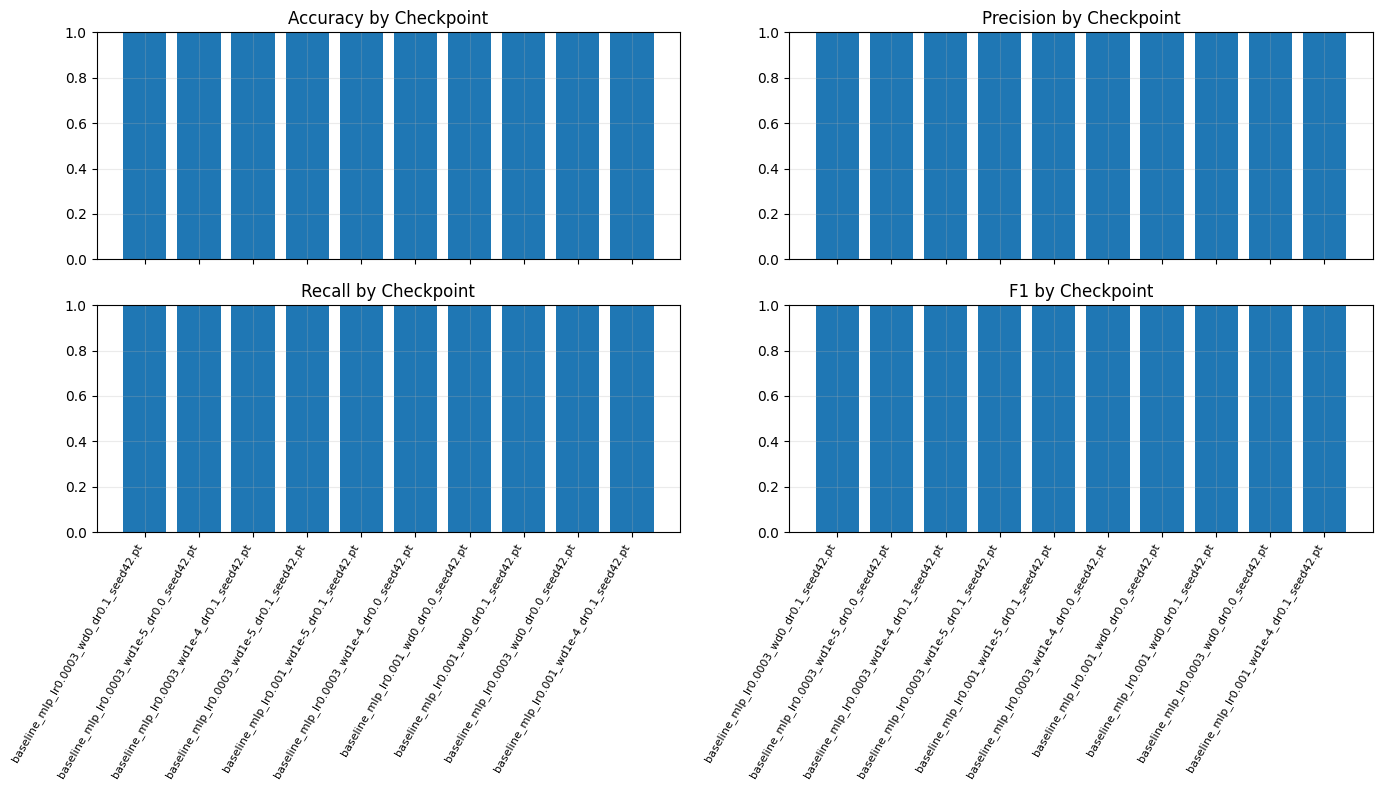

Best checkpoint: baseline_mlp_lr0.0003_wd0_dr0.1_seed42.pt
Best threshold : 0.30
Best metrics   : acc=0.995692,  prec=0.999010,  rec=0.994759,  f1=0.996880


In [7]:
top = ranked[: min(TOP_K_PLOTS, len(ranked))]
names = [r['checkpoint_name'] for r in top]
x = np.arange(len(top))

acc_vals = [r['accuracy'] for r in top]
prec_vals = [r['precision'] for r in top]
rec_vals = [r['recall'] for r in top]
f1_vals = [r['f1'] for r in top]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.ravel()

axes[0].bar(x, acc_vals)
axes[0].set_title('Accuracy by Checkpoint')
axes[0].set_ylim(0, 1)

axes[1].bar(x, prec_vals)
axes[1].set_title('Precision by Checkpoint')
axes[1].set_ylim(0, 1)

axes[2].bar(x, rec_vals)
axes[2].set_title('Recall by Checkpoint')
axes[2].set_ylim(0, 1)

axes[3].bar(x, f1_vals)
axes[3].set_title('F1 by Checkpoint')
axes[3].set_ylim(0, 1)

for ax in axes:
    ax.grid(alpha=0.25)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=60, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

print('Best checkpoint:', best_model['checkpoint_name'])
print('Best threshold :', f"{best_threshold:.2f}")
print('Best metrics   :',
      f"acc={best_model['accuracy']:.6f}, ",
      f"prec={best_model['precision']:.6f}, ",
      f"rec={best_model['recall']:.6f}, ",
      f"f1={best_model['f1']:.6f}")

**Output explanation**

These plots show that all checkpoints achieve consistently very high performance across accuracy, precision, recall, and F1, with values all close to 1.0. There is minimal variation between different hyperparameter settings, indicating that the model is robust and not highly sensitive to changes in learning rate, weight decay, or dropout. Precision is slightly higher than recall across most checkpoints, suggesting the model is slightly conservative in predicting speech, but still maintains strong balance as reflected in the high F1 scores. Overall, the results confirm that the baseline MLP performs extremely well on the clean dataset and that hyperparameter tuning provides only marginal improvements.

### Step 8: Visualize confusion matrix for best checkpoint
This step plots the confusion matrix of the selected best model using its tuned decision threshold.

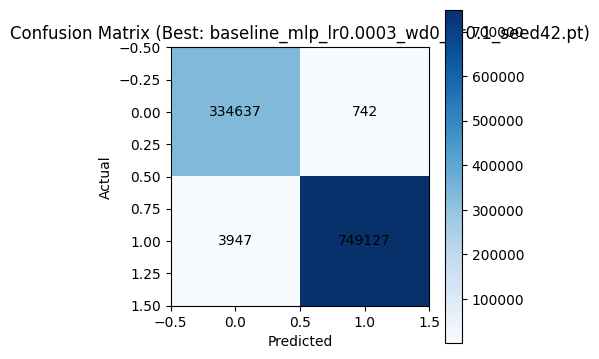

In [8]:
cm = confusion_matrix(all_labels, preds)

plt.figure(figsize=(4.5, 4.0))
plt.imshow(cm, cmap='Blues')
plt.title(f"Confusion Matrix (Best: {best_model['checkpoint_name']})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

**Output explanation**

This confusion matrix shows that the best-performing model makes very few errors when classifying speech and non-speech frames. The model correctly identifies 334,637 non-speech frames and 749,127 speech frames, while only misclassifying 742 non-speech frames as speech (false positives) and 3,947 speech frames as non-speech (false negatives). This indicates that the model achieves extremely high accuracy, with very low error rates overall. The number of false negatives is slightly higher than false positives, which aligns with earlier observations that the model is somewhat conservative in predicting speech. Overall, the confusion matrix confirms that the model performs very reliably on clean data, with strong balance between precision and recall.

### Step 9: Plot ROC curve for best checkpoint
This step computes and visualizes the ROC curve and AUC for the selected best model on dev-clean.

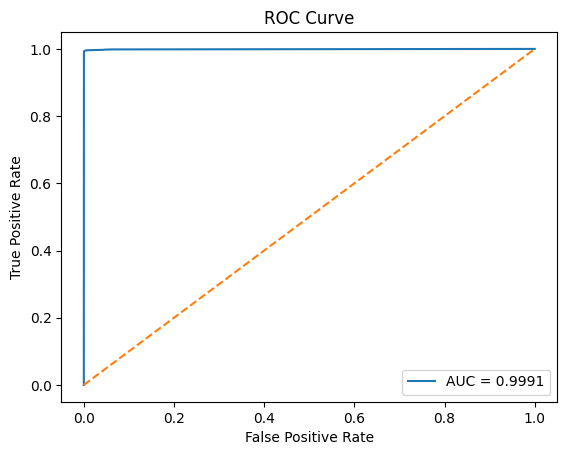

In [9]:
fpr, tpr, _ = roc_curve(all_labels, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Output explanation**

The ROC curve shows that the model achieves near-perfect discrimination between speech and non-speech frames, with an AUC of 0.9991. The curve rises sharply toward the top-left corner, indicating that the model can achieve a very high true positive rate while maintaining an extremely low false positive rate across different thresholds. This means the model is highly effective at separating the two classes, and its performance remains strong regardless of the decision threshold chosen. Overall, the ROC curve confirms that the baseline MLP is exceptionally well-suited for this task under clean conditions.

### Step 10: Plot precision-recall curve for best checkpoint
This step visualizes the precision-recall trade-off, which is often informative for imbalanced frame-level classification tasks.

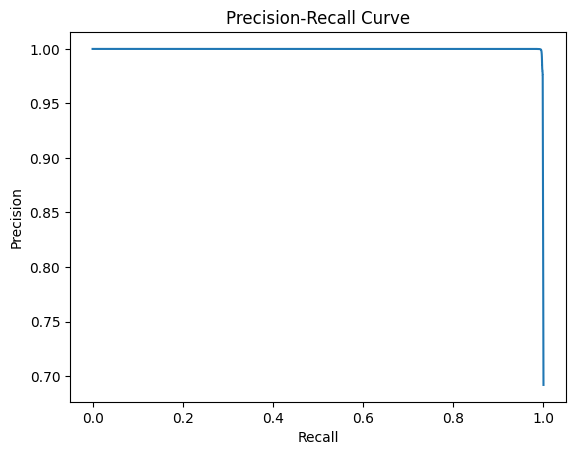

In [10]:
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, probs)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

**Output explanation**

The precision–recall curve shows that the model maintains near-perfect precision across almost the entire range of recall, staying close to 1.0 until recall approaches its maximum. This indicates that the model makes very few false positive errors while successfully identifying most speech frames. Only at extremely high recall does precision begin to drop slightly, reflecting the trade-off when trying to capture every possible speech frame. Overall, the curve demonstrates that the model achieves an excellent balance between precision and recall and performs very reliably on the clean dataset.

### Step 11: Re-check threshold sweep on best checkpoint
This step recomputes F1 across thresholds for the selected best checkpoint and verifies the chosen operating point.

In [11]:
thresholds = THRESHOLDS
f1_scores = []

for t in thresholds:
    preds_t = (probs >= t).astype(int)
    f1_scores.append(f1_score(all_labels, preds_t))

best_idx = int(np.argmax(f1_scores))
best_threshold_from_curve = float(thresholds[best_idx])

print('Best checkpoint       :', best_model['checkpoint_name'])
print('Best threshold (saved):', best_threshold)
print('Best threshold (curve):', best_threshold_from_curve)
print('Best F1 (curve)       :', f1_scores[best_idx])

Best checkpoint       : baseline_mlp_lr0.0003_wd0_dr0.1_seed42.pt
Best threshold (saved): 0.3
Best threshold (curve): 0.3
Best F1 (curve)       : 0.9968801212022013


**Output explanation**

The best-performing model is the checkpoint trained with a learning rate of 0.0003, no weight decay, and a dropout of 0.1. Both the saved threshold and the optimal threshold from the precision–recall curve are 0.3, indicating consistent threshold tuning. At this threshold, the model achieves an F1 score of approximately 0.9969, confirming its excellent performance. This result shows that a slightly lower decision threshold than the default improves the balance between precision and recall, and that this configuration provides the most effective overall performance on the validation data.

### Step 12: Visualize F1 versus threshold
This step plots the F1-threshold curve for the best checkpoint to make threshold behavior easy to inspect.

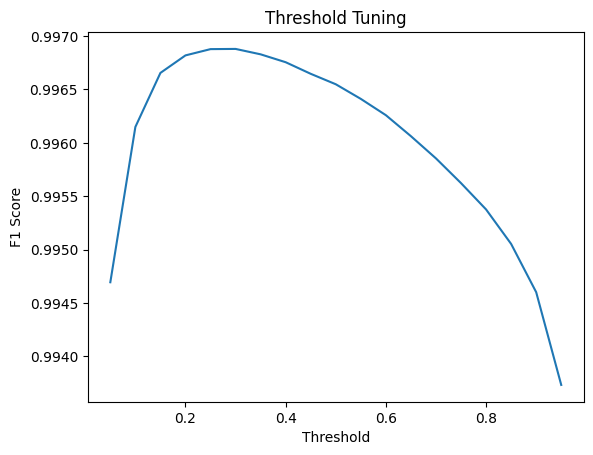

In [12]:
plt.figure()
plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Tuning")
plt.show()

**Output explanation**

The threshold tuning curve shows how the F1 score changes as the decision threshold varies. The F1 score increases as the threshold rises from very low values and reaches its peak around 0.3, indicating the optimal balance between precision and recall. Beyond this point, the F1 score gradually decreases as the threshold continues to increase, suggesting that the model becomes too conservative and starts missing more speech frames (lower recall). At very low thresholds, the model predicts too many frames as speech, which slightly hurts precision. Overall, the curve confirms that a threshold of 0.3 provides the best trade-off and aligns with the previously identified optimal setting.

### Step 13: Export evaluation artifacts and tuned configuration
This step saves prediction arrays, the checkpoint leaderboard, and the final tuned config for reproducible downstream testing/reporting.

In [13]:
eval_dir = ARTIFACTS_DIR / 'eval_outputs_clean'
eval_dir.mkdir(parents=True, exist_ok=True)

np.save(eval_dir / 'eval_logits.npy', all_logits)
np.save(eval_dir / 'eval_probs.npy', probs)
np.save(eval_dir / 'eval_labels.npy', all_labels)

with open(eval_dir / 'checkpoint_leaderboard.json', 'w', encoding='utf-8') as f:
    json.dump(
        [
            {
                'checkpoint': r['checkpoint'],
                'checkpoint_name': r['checkpoint_name'],
                'best_threshold': r['best_threshold'],
                'accuracy': r['accuracy'],
                'precision': r['precision'],
                'recall': r['recall'],
                'f1': r['f1'],
                'tp': r['tp'],
                'tn': r['tn'],
                'fp': r['fp'],
                'fn': r['fn'],
            }
            for r in ranked
        ],
        f,
        indent=2,
    )

clean_config_path = ARTIFACTS_DIR / 'final_tuned_config_clean.json'
with open(clean_config_path, 'w', encoding='utf-8') as f:
    json.dump(
        {
            'checkpoint': best_model['checkpoint'],
            'threshold': best_threshold,
            'dev_metrics': {
                'accuracy': best_model['accuracy'],
                'precision': best_model['precision'],
                'recall': best_model['recall'],
                'f1': best_model['f1'],
                'tp': best_model['tp'],
                'tn': best_model['tn'],
                'fp': best_model['fp'],
                'fn': best_model['fn'],
            },
        },
        f,
        indent=2,
    )

print('Saved evaluation arrays to:', eval_dir)
print('Saved leaderboard to     :', eval_dir / 'checkpoint_leaderboard.json')
print('Saved tuned config to    :', clean_config_path)

Saved evaluation arrays to: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/eval_outputs_clean
Saved leaderboard to     : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/eval_outputs_clean/checkpoint_leaderboard.json
Saved tuned config to    : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/final_tuned_config_clean.json
